### Import Analytics Tools/libraries for project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os 

### Extract the data 

In [4]:
os.listdir(r"C:\Users\sunda\Downloads\Uber\Datasets")

['other-American_B01362.csv',
 'other-Carmel_B00256.csv',
 'other-Dial7_B00887.csv',
 'other-Diplo_B01196.csv',
 'other-Federal_02216.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Highclass_B01717.csv',
 'other-Lyft_B02510.csv',
 'other-Prestige_B01338.csv',
 'other-Skyline_B00111.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-janjune-15.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv']

In [9]:
pd.read_csv (r"C:\Users\sunda\Downloads\Uber\Datasets\uber-raw-data-janjune-15.csv")

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90
...,...,...,...,...
14270474,B02765,2015-05-08 15:43:00,B02765,186
14270475,B02765,2015-05-08 15:43:00,B02765,263
14270476,B02765,2015-05-08 15:43:00,B02765,90
14270477,B02765,2015-05-08 15:44:00,B01899,45


In [12]:


uber_15 = pd.read_csv(r"C:\Users\sunda\Downloads\Uber\Datasets\uber-raw-data-janjune-15.csv")

In [14]:
uber_15.duplicated()

0           False
1           False
2           False
3           False
4           False
            ...  
14270474    False
14270475    False
14270476    False
14270477    False
14270478    False
Length: 14270479, dtype: bool

### Transform Data (Data Cleaning) Missing values, duplicate data

In [16]:
uber_15.shape

(14270479, 4)

In [17]:
#show duplicates in dataframe
uber_15[uber_15.duplicated(keep=False)]

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
14,B02617,2015-05-17 09:49:00,B02617,237
17,B02617,2015-05-17 09:49:00,B02617,237
67,B02617,2015-05-17 09:59:00,B02617,48
70,B02617,2015-05-17 09:59:00,B02617,48
74,B02617,2015-05-17 10:00:00,B02617,141
...,...,...,...,...
14270418,B02765,2015-05-08 15:34:00,B02765,243
14270424,B02765,2015-05-08 15:35:00,B02765,90
14270428,B02765,2015-05-08 15:35:00,B02765,90
14270431,B02765,2015-05-08 15:36:00,B02765,237


In [20]:
###sort duplicates in every column

uber_15[uber_15.duplicated(keep=False)] .sort_values(by=uber_15.columns.tolist())

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
6901294,B02512,2015-01-01 00:02:29,NaN,161
6901632,B02512,2015-01-01 00:02:29,NaN,161
6901313,B02512,2015-01-01 00:10:07,B02682,188
6901560,B02512,2015-01-01 00:10:07,B02682,188
6900994,B02512,2015-01-01 00:29:49,B02512,87
...,...,...,...,...
14085491,B02835,2015-06-30 21:44:00,B02835,231
14085554,B02835,2015-06-30 22:10:00,B02835,161
14085557,B02835,2015-06-30 22:10:00,B02835,161
14085615,B02835,2015-06-30 22:34:00,B02835,125


In [28]:
#Drop duplicates 

uber_15.drop_duplicates(inplace=True)


In [27]:
#check if there is any duplicate left
uber_15.duplicated().sum()

np.int64(0)

In [29]:
#Check dataframe deleteing duplicates
uber_15.shape

(13372254, 4)

In [32]:
# Next Remove Null values (empty/missing entry)
uber_15.isnull ()



,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
14270474,False,False,False,False
14270475,False,False,False,False
14270476,False,False,False,False
14270477,False,False,False,False


uber_15.isnull ().sum()

In [36]:
### Decide whether to skip, delete or fill null/missing entry. if missing entries are important part of anlysis fill, and if not skip or delete.
###in our project we will skip the null as the column is not important to our analysis.

#Next is to correct datatypes
uber_15.dtypes


Dispatching_base_num    object
Pickup_date             object
Affiliated_base_num     object
locationID               int64
dtype: object

In [39]:
#correct the datatype for pickup_date column
uber_15['Pickup_date'] = pd.to_datetime(uber_15['Pickup_date'])

In [40]:
uber_15.dtypes

Dispatching_base_num            object
Pickup_date             datetime64[ns]
Affiliated_base_num             object
locationID                       int64
dtype: object

#Begin Analysis.
Which month have the max uber pick_up in New york city?

In [41]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90
...,...,...,...,...
14270474,B02765,2015-05-08 15:43:00,B02765,186
14270475,B02765,2015-05-08 15:43:00,B02765,263
14270476,B02765,2015-05-08 15:43:00,B02765,90
14270477,B02765,2015-05-08 15:44:00,B01899,45


In [45]:
uber_15["month"]=uber_15['Pickup_date'].dt.month_name()
uber_15["weekday"]= uber_15['Pickup_date'].dt.day_name()
uber_15["day"]= uber_15['Pickup_date'].dt.day
uber_15["hour"]= uber_15['Pickup_date'].dt.hour
uber_15["minute"]= uber_15['Pickup_date'].dt.minute

In [46]:
uber_15["month"]

0           May
1           May
2           May
3           May
4           May
           ... 
14270474    May
14270475    May
14270476    May
14270477    May
14270478    May
Name: month, Length: 13372254, dtype: object

In [47]:
uber_15["weekday"]

0           Sunday
1           Sunday
2           Sunday
3           Sunday
4           Sunday
             ...  
14270474    Friday
14270475    Friday
14270476    Friday
14270477    Friday
14270478    Friday
Name: weekday, Length: 13372254, dtype: object

In [48]:
uber_15["day"]

0           17
1           17
2           17
3           17
4           17
            ..
14270474     8
14270475     8
14270476     8
14270477     8
14270478     8
Name: day, Length: 13372254, dtype: int32

In [50]:
# we can use the value_counts function to know the month with the hightest pick_ups

uber_15["month"].value_counts()

month
June        2571771
May         2483980
February    2222189
April       2112705
March       2062639
January     1918970
Name: count, dtype: int64

<Axes: xlabel='month'>

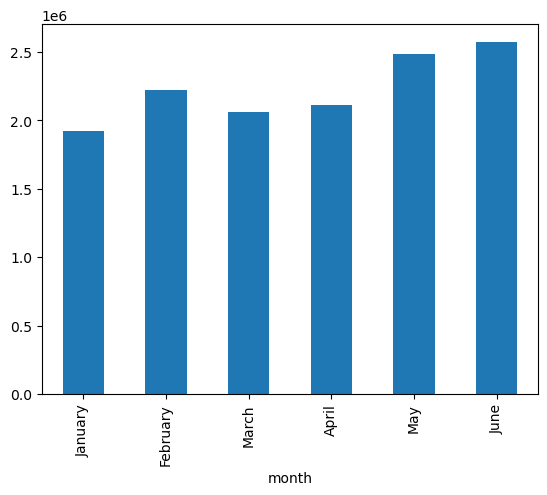

In [88]:
month_counts = uber_15["month"].value_counts()
month_order = ["January","February","March","April","May","June"]
month_counts = month_counts.reindex(month_order)
month_counts.plot(kind='bar')


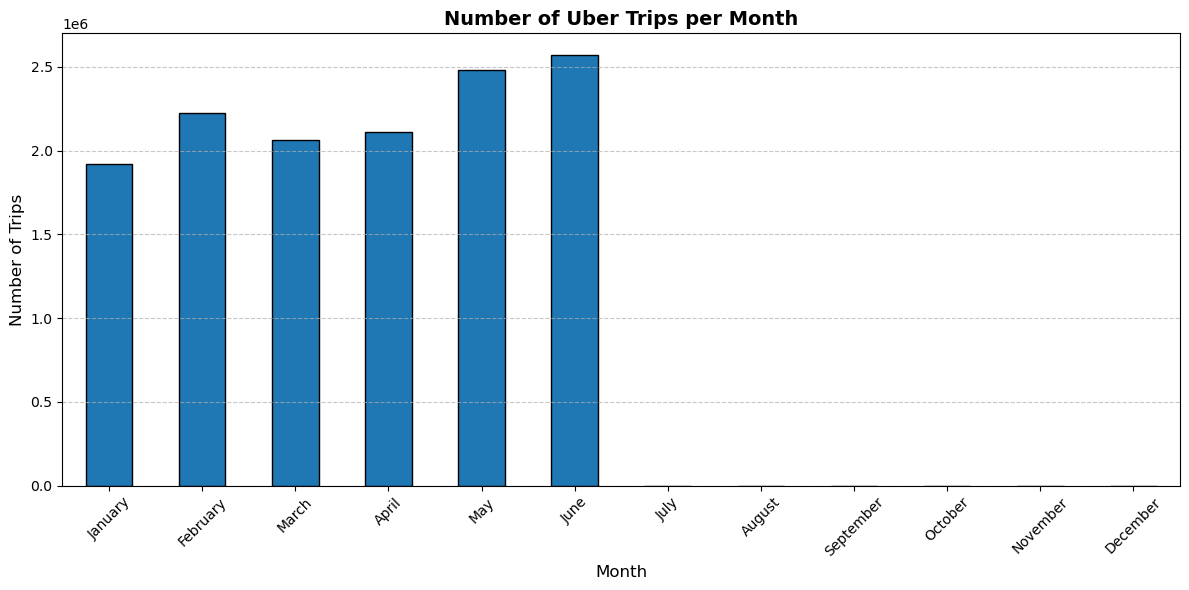

In [82]:
##Create a better barchart with title and lable for easy readability



month_counts = uber_15["month"].value_counts().sort_index()

plt.figure(figsize=(12,6))  # better width for readability

month_counts.plot(kind='bar', edgecolor='black')

plt.title("Number of Uber Trips per Month", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)

# Let pandas handle labels automatically
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()  # prevents cutting off labels
plt.show()

In [71]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,weekday,day,hour,minute
0,B02617,2015-05-17 09:47:00,B02617,141,May,Sunday,17,9,47
1,B02617,2015-05-17 09:47:00,B02617,65,May,Sunday,17,9,47
2,B02617,2015-05-17 09:47:00,B02617,100,May,Sunday,17,9,47
3,B02617,2015-05-17 09:47:00,B02774,80,May,Sunday,17,9,47


In [97]:
# Desired month and weekday order
month_order = ["January","February","March","April","May","June"]
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

pivot = pd.crosstab(index=uber_15['month'], columns=uber_15['weekday'])

pivot = pivot.reindex(index=month_order, columns=weekday_order)
pivot


weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
month,,,,,,,
January,190606,196574,245650,330319,339285,386049,230487
February,274948,287260,286387,335603,373550,368311,296130
March,269931,320634,256767,277026,309631,314785,313865
April,238429,250632,338015,372522,315002,324545,273560
May,255501,290004,316045,337607,430134,464298,390391
June,375312,405500,328141,357782,371225,399377,334434


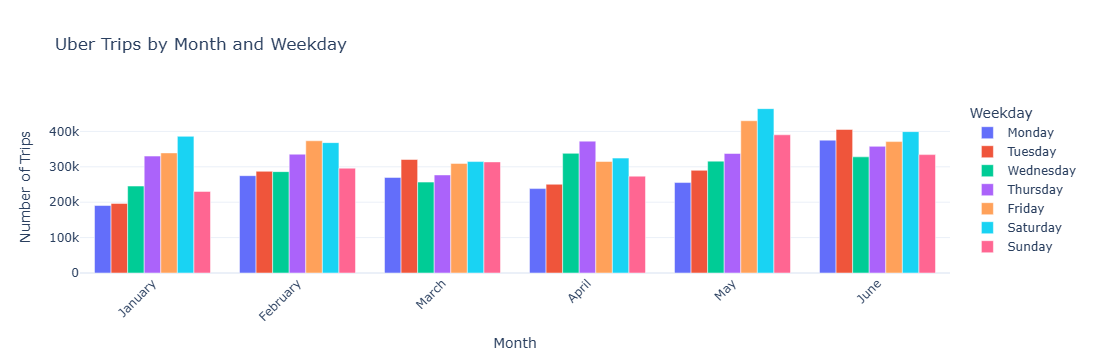

In [104]:
#create a grouped bar xhat

fig = px.bar(
    pivot,                     # your crosstab DataFrame
    x=pivot.index,             # months
    y=pivot.columns,           # weekdays
    barmode='group',           # grouped bars
    title="Uber Trips by Month and Weekday"
)
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Number of Trips",
    legend_title="Weekday",
    xaxis_tickangle=-45,
    template="plotly_white"
)
fig.show()

Observation:
From the grouped bar chart, it is clear that Fridays and Saturdays consistently experience the highest number of Uber rides, indicating these are the peak days for ride demand. In contrast, weekdays such as Monday through Wednesday show relatively lower ride volumes, suggesting lower commuting or leisure activity. This pattern highlights a weekday-weekend variation in ride usage, which could be valuable for resource allocation, driver scheduling, and promotional strategies to optimize service during high-demand periods.